<a href="https://colab.research.google.com/github/mamun-career-tech/Cervical_Cancer_Prediction_ML_and_DL/blob/main/Cervical_Cancer_XgBoost%2BKbest%2BPCA%2BAll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Import Section


import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# @title Dataset Read


Cervical_Cancer_Data = pd.read_csv('/content/risk_factors_cervical_cancer4.csv')
#Cervical_Cancer_Data
Cervical_Cancer_Data


,Age,First_sexual_intercourse,Num_of_pregnancies,Smokes,Smokes_years,Smokes_packs_per_year,Hormonal_Contraceptives,Hormonal_Contraceptives_years,IUD,IUD_years,...,STDs_Time_since_first_diagnosis,STDs_Time_since_last_diagnosis,Dx_Cancer,Dx_CIN,Dx_HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,15,1,0,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
1,15,14,1,0,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
2,34,?,1,0,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
3,52,16,4,1,37,37,1,3,0,0,...,?,?,1,0,1,0,0,0,0,0
4,46,21,4,0,0,0,1,15,0,0,...,?,?,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,18,0,0,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
854,32,19,1,0,0,0,1,8,0,0,...,?,?,0,0,0,0,0,0,0,0
855,25,17,0,0,0,0,1,0.08,0,0,...,?,?,0,0,0,0,0,0,1,0
856,33,24,2,0,0,0,1,0.08,0,0,...,?,?,0,0,0,0,0,0,0,0


In [ ]:
Cervical_Cancer_Data.isnull().sum().sum()

0

In [ ]:
Cervical_Cancer_Data_mean = Cervical_Cancer_Data.mean()
Cervical_Cancer_Data = Cervical_Cancer_Data.fillna(Cervical_Cancer_Data_mean)

<ipython-input-4-4872957701b4>:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  Cervical_Cancer_Data_mean = Cervical_Cancer_Data.mean()


In [ ]:
le = LabelEncoder()

Cervical_Cancer_Data.Age = le.fit_transform(Cervical_Cancer_Data['Age'])
#Cervical_Cancer_Data.Number_of_sexual_partners = le.fit_transform(Cervical_Cancer_Data['Number_of_sexual_partners'])
Cervical_Cancer_Data.First_sexual_intercourse = le.fit_transform(Cervical_Cancer_Data['First_sexual_intercourse'])
Cervical_Cancer_Data.Num_of_pregnancies = le.fit_transform(Cervical_Cancer_Data['Num_of_pregnancies'])
Cervical_Cancer_Data.Smokes = le.fit_transform(Cervical_Cancer_Data['Smokes'])
Cervical_Cancer_Data.Smokes_years = le.fit_transform(Cervical_Cancer_Data['Smokes_years'])
Cervical_Cancer_Data.Smokes_packs_per_year = le.fit_transform(Cervical_Cancer_Data['Smokes_packs_per_year'])
Cervical_Cancer_Data.Hormonal_Contraceptives = le.fit_transform(Cervical_Cancer_Data['Hormonal_Contraceptives'])
Cervical_Cancer_Data.Hormonal_Contraceptives_years = le.fit_transform(Cervical_Cancer_Data['Hormonal_Contraceptives_years'])
Cervical_Cancer_Data.IUD = le.fit_transform(Cervical_Cancer_Data['IUD'])
Cervical_Cancer_Data.IUD_years = le.fit_transform(Cervical_Cancer_Data['IUD_years'])
#Cervical_Cancer_Data.STDs = le.fit_transform(Cervical_Cancer_Data['STDs'])
#Cervical_Cancer_Data.STDs_number = le.fit_transform(Cervical_Cancer_Data['STDs_number'])
#Cervical_Cancer_Data.STDs_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_condylomatosis'])
#Cervical_Cancer_Data.STDs_cervical_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_cervical_condylomatosis'])
Cervical_Cancer_Data.STDs_vaginal_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_vaginal_condylomatosis'])
Cervical_Cancer_Data.STDs_vulvo_perineal_condylomatosis = le.fit_transform(Cervical_Cancer_Data['STDs_vulvo_perineal_condylomatosis'])
Cervical_Cancer_Data.STDs_syphilis = le.fit_transform(Cervical_Cancer_Data['STDs_syphilis'])
Cervical_Cancer_Data.STDs_pelvic_inflammatory_disease = le.fit_transform(Cervical_Cancer_Data['STDs_pelvic_inflammatory_disease'])
#Cervical_Cancer_Data.STDs_genital_herpes = le.fit_transform(Cervical_Cancer_Data['STDs_genital_herpes'])
#Cervical_Cancer_Data.STDs_molluscum_contagiosum = le.fit_transform(Cervical_Cancer_Data['STDs_molluscum_contagiosum'])
#Cervical_Cancer_Data.STDs_AIDS = le.fit_transform(Cervical_Cancer_Data['STDs_AIDS'])
Cervical_Cancer_Data.STDs_HIV = le.fit_transform(Cervical_Cancer_Data['STDs_HIV'])
Cervical_Cancer_Data.STDs_Hepatitis_B = le.fit_transform(Cervical_Cancer_Data['STDs_Hepatitis_B'])
Cervical_Cancer_Data.STDs_HPV = le.fit_transform(Cervical_Cancer_Data['STDs_HPV'])
Cervical_Cancer_Data.STDs_Number_of_diagnosis = le.fit_transform(Cervical_Cancer_Data['STDs_Number_of_diagnosis'])
Cervical_Cancer_Data.STDs_Time_since_first_diagnosis = le.fit_transform(Cervical_Cancer_Data['STDs_Time_since_first_diagnosis'])
Cervical_Cancer_Data.STDs_Time_since_last_diagnosis = le.fit_transform(Cervical_Cancer_Data['STDs_Time_since_last_diagnosis'])
Cervical_Cancer_Data.Dx_Cancer = le.fit_transform(Cervical_Cancer_Data['Dx_Cancer'])
Cervical_Cancer_Data.Dx_CIN = le.fit_transform(Cervical_Cancer_Data['Dx_CIN'])
Cervical_Cancer_Data.Dx_HPV = le.fit_transform(Cervical_Cancer_Data['Dx_HPV'])
Cervical_Cancer_Data.Dx = le.fit_transform(Cervical_Cancer_Data['Dx'])
Cervical_Cancer_Data.Hinselmann = le.fit_transform(Cervical_Cancer_Data['Hinselmann'])
Cervical_Cancer_Data.Schiller = le.fit_transform(Cervical_Cancer_Data['Schiller'])
Cervical_Cancer_Data.Citology = le.fit_transform(Cervical_Cancer_Data['Citology'])
Cervical_Cancer_Data.Biopsy = le.fit_transform(Cervical_Cancer_Data['Biopsy'])

In [ ]:
x = Cervical_Cancer_Data.drop(['Biopsy'], axis = 1)
y = Cervical_Cancer_Data['Biopsy']

In [ ]:
mutual_info = mutual_info_classif(x,y)
mutual_info = pd.Series(mutual_info)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

Schiller                              0.125454
Hinselmann                            0.076753
Dx                                    0.023320
STDs_syphilis                         0.022115
Dx_HPV                                0.021711
Citology                              0.017976
STDs_pelvic_inflammatory_disease      0.014418
Hormonal_Contraceptives               0.011999
Dx_Cancer                             0.011152
First_sexual_intercourse              0.008455
Hormonal_Contraceptives_years         0.007370
STDs_vaginal_condylomatosis           0.006977
IUD_years                             0.005658
STDs_Time_since_first_diagnosis       0.004082
STDs_Number_of_diagnosis              0.003234
STDs_Hepatitis_B                      0.003171
STDs_HPV                              0.002740
STDs_HIV                              0.001618
Dx_CIN                                0.001242
Smokes_years                          0.000043
IUD                                   0.000000
STDs_Time_sin

In [ ]:
#plt.figure(figsize = (35,15))
#sns.heatmap(Cervical_Cancer_Data.corr(), annot = True, cmap="BuPu")

In [ ]:
Scaler = StandardScaler()
Scaler.fit(x)
Scaled_x = Scaler.transform(x)
print(Scaled_x)

Pca = PCA(n_components = 19)
Pca.fit(Scaled_x)
Pca_x = Pca.transform(Scaled_x)
Pca_x.shape

[[-1.08926764 -0.69069522 -1.08276722 ... -0.20622158 -0.3072259
  -0.23249528]
 [-1.46420411 -1.01846984 -1.08276722 ... -0.20622158 -0.3072259
  -0.23249528]
 [ 0.91039352  4.5536986  -1.08276722 ... -0.20622158 -0.3072259
  -0.23249528]
 ...
 [-0.21441588 -0.035146   -1.44076887 ... -0.20622158 -0.3072259
   4.30116263]
 [ 0.7854147   2.2592763  -0.00876228 ... -0.20622158 -0.3072259
  -0.23249528]
 [ 0.28549941  0.94817785 -1.08276722 ... -0.20622158 -0.3072259
  -0.23249528]]


(858, 19)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(Pca_x,y,test_size = 0.30)#random_state=20

In [ ]:
# @title Machine Learning Model

# Support Vector Machine (SVM)
svm = SVC().fit(x_train, y_train)

# Random Forest (RF)
RF = RandomForestClassifier().fit(x_train, y_train)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier().fit(x_train, y_train)

# Decision Tree (DT)
DT = DecisionTreeClassifier().fit(x_train, y_train)

# Naive Bayes (NB)
NB = GaussianNB().fit(x_train, y_train)

# Logistic Regression (LR)
LR = LogisticRegression(solver='liblinear',max_iter=3000).fit(x_train, y_train)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier().fit(x_train, y_train)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier().fit(x_train, y_train)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier().fit(x_train, y_train)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid().fit(x_train, y_train)

# Voting Classifier (VC)
est = [('svm',svm), ('lr',LR)]
VC = VotingClassifier(estimators = est, voting ='hard').fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Support Vector Machine (SVM)
svm_pre = svm.predict(x_test)
svm_sc = svm.score(x_test, y_test) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
rf_pre = RF.predict(x_test)
RF_sc = RF.score(x_test, y_test) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
knn_pre = KNN.predict(x_test)
KNN_sc = KNN.score(x_test, y_test) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
dt_pre = DT.predict(x_test)
DT_sc = DT.score(x_test, y_test) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
nb_pre = NB.predict(x_test)
NB_sc = NB.score(x_test, y_test) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
lr_pre = LR.predict(x_test)
LR_sc = LR.score(x_test, y_test) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
ab_pre = AB.predict(x_test)
AB_sc = AB.score(x_test, y_test) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
gb_pre = GB.predict(x_test)
GB_sc = GB.score(x_test, y_test) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
mlp_pre = MLP.predict(x_test)
MLP_sc = MLP.score(x_test, y_test) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
ncc_pre = NCC.predict(x_test)
NCC_sc = NCC.score(x_test, y_test) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

# Voting Classifier (VC)
vc_pre = VC.predict(x_test)
vc_sc = VC.score(x_test, y_test) * 100
vc_sc = "{:.2f}".format(vc_sc)

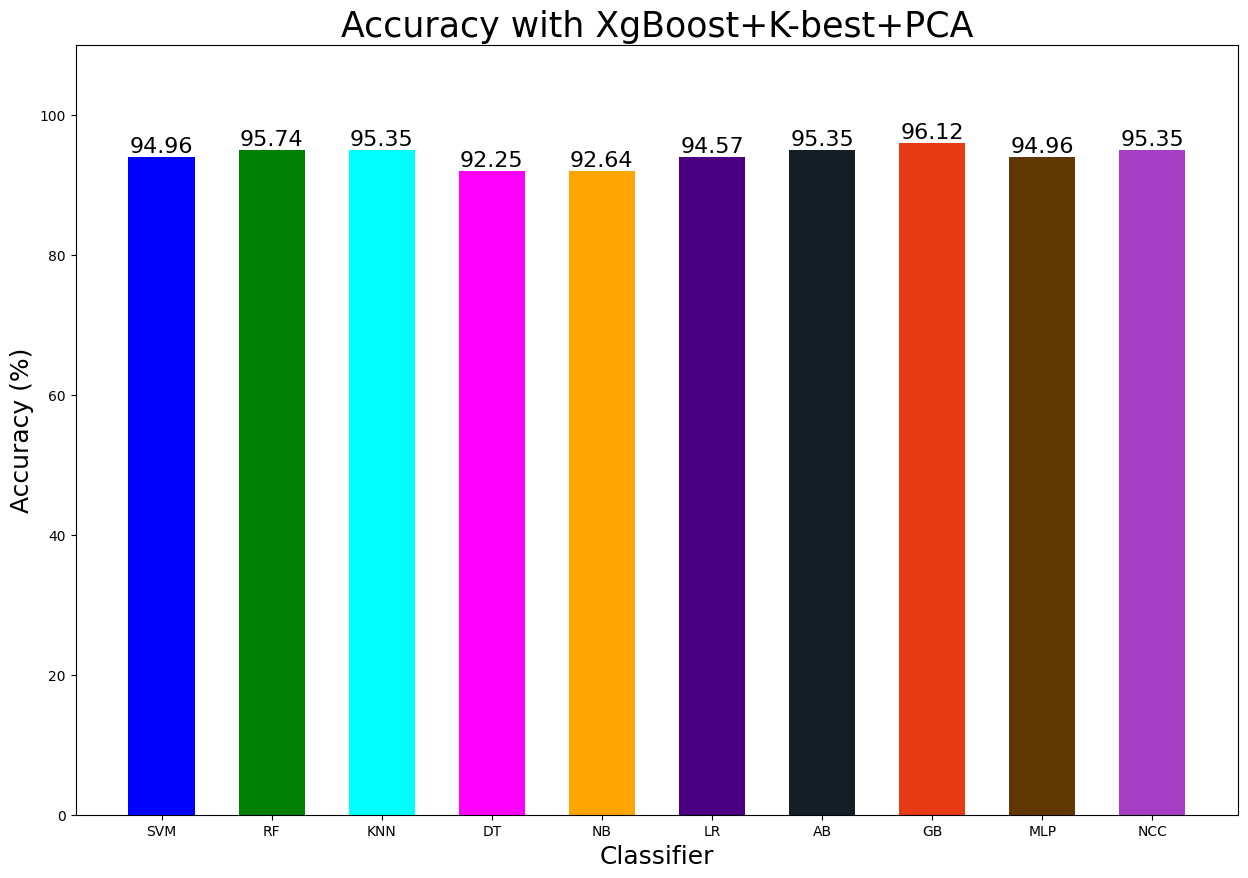

In [ ]:
plt.figure(figsize=(15,10))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5']
plt.bar(algo, acc, color=colors, width=0.6)
plt.title('Accuracy with XgBoost+K-best+PCA', color = 'black', fontsize= 25)
plt.xlabel('Classifier', fontsize= 18)
plt.ylabel('Accuracy (%)', fontsize= 18)
plt.ylim(0,110)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

In [ ]:
os = RandomOverSampler(sampling_strategy=1)
x_os, y_os = os.fit_resample(Pca_x,y)
print("Before fit {}".format(Counter(y)))
print("After fit {}".format(Counter(y_os)))

Before fit Counter({0: 803, 1: 55})
After fit Counter({0: 803, 1: 803})


In [ ]:
C = 15

In [ ]:
#Support Vector Machine (SVM)
svm = SVC(C= 1000, gamma= 0.0001, kernel= 'rbf')
svm_y_pre = cross_val_predict(svm, x_os, y_os, cv=C)
svm_sc = accuracy_score(y_os, svm_y_pre) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
RF = RandomForestClassifier()
rf_y_pre = cross_val_predict(RF, x_os, y_os, cv=C)
RF_sc = accuracy_score(y_os, rf_y_pre) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier(n_neighbors= 1, weights= 'uniform')
knn_y_pre = cross_val_predict(KNN, x_os, y_os, cv=C)
KNN_sc = accuracy_score(y_os, knn_y_pre) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
DT = DecisionTreeClassifier(criterion= 'gini', max_depth= 20, min_samples_leaf= 5)
dt_y_pre = cross_val_predict(DT, x_os, y_os, cv=C)
DT_sc = accuracy_score(y_os, dt_y_pre) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
NB = GaussianNB()
nb_y_pre = cross_val_predict(NB, x_os, y_os, cv=5)
NB_sc = accuracy_score(y_os, nb_y_pre) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
LR = LogisticRegression(max_iter=3000,C= 1.0, penalty= 'l2', solver= 'liblinear')
lr_y_pre = cross_val_predict(LR, x_os, y_os, cv=5)
LR_sc = accuracy_score(y_os, lr_y_pre) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier()
ab_y_pre = cross_val_predict(AB, x_os, y_os, cv=C)
AB_sc = accuracy_score(y_os, ab_y_pre) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier()
gb_y_pre = cross_val_predict(GB, x_os, y_os, cv=C)
GB_sc = accuracy_score(y_os, gb_y_pre) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier(max_iter=3000)
mlp_y_pre = cross_val_predict(MLP, x_os, y_os, cv=C)
MLP_sc = accuracy_score(y_os, mlp_y_pre) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid()
ncc_y_pre = cross_val_predict(NCC, x_os, y_os, cv=C)
NCC_sc = accuracy_score(y_os, ncc_y_pre) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

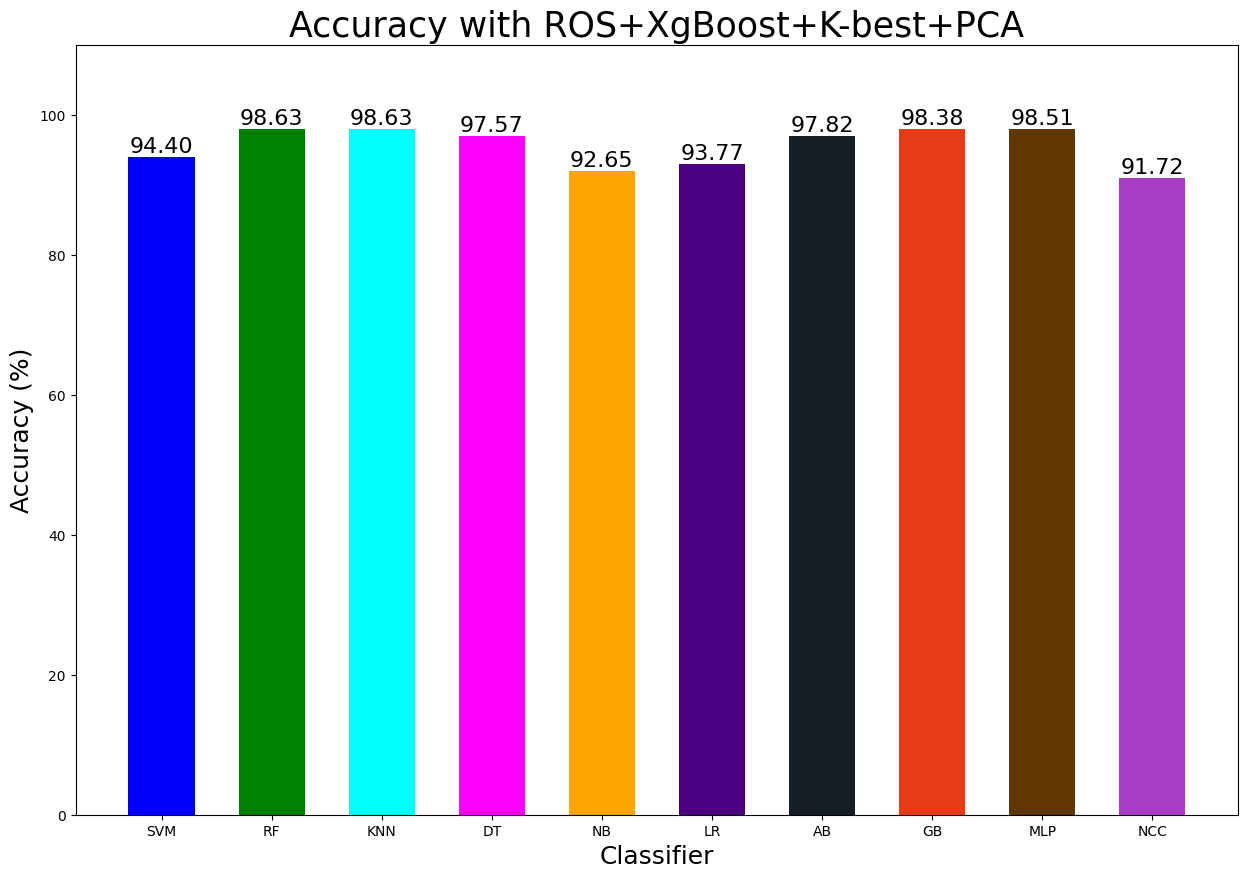

In [ ]:
plt.figure(figsize=(15,10))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5']
plt.bar(algo, acc, color=colors, width=0.6)
plt.title('Accuracy with ROS+XgBoost+K-best+PCA', color = 'black', fontsize= 25)
plt.xlabel('Classifier', fontsize= 18)
plt.ylabel('Accuracy (%)', fontsize= 18)
plt.ylim(0,110)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

In [ ]:
def VotingClassifierMethod(est, Type):
    vot = VotingClassifier(estimators = est, voting = Type)
    vc_y_pre = cross_val_predict(vot, x_os, y_os, cv=C)
    vc_sc = accuracy_score(y_os, vc_y_pre) * 100
    vc_sc = "{:.2f}".format(vc_sc)
    return vc_sc


est1 = [('gb',KNN), ('rf',RF)]
est2 = [('gb',KNN), ('mlp',MLP)]
est3 = [('rf',RF), ('mlp',MLP)]
est4 = [('gb',KNN), ('rf',RF), ('mlp',MLP)]

a1 = VotingClassifierMethod(est1, 'hard')
b1 = VotingClassifierMethod(est1, 'soft')

a2 = VotingClassifierMethod(est2, 'hard')
b2 = VotingClassifierMethod(est2, 'soft')

a3 = VotingClassifierMethod(est3, 'hard')
b3 = VotingClassifierMethod(est3, 'soft')

a4 = VotingClassifierMethod(est4, 'hard')
b4 = VotingClassifierMethod(est4, 'soft')

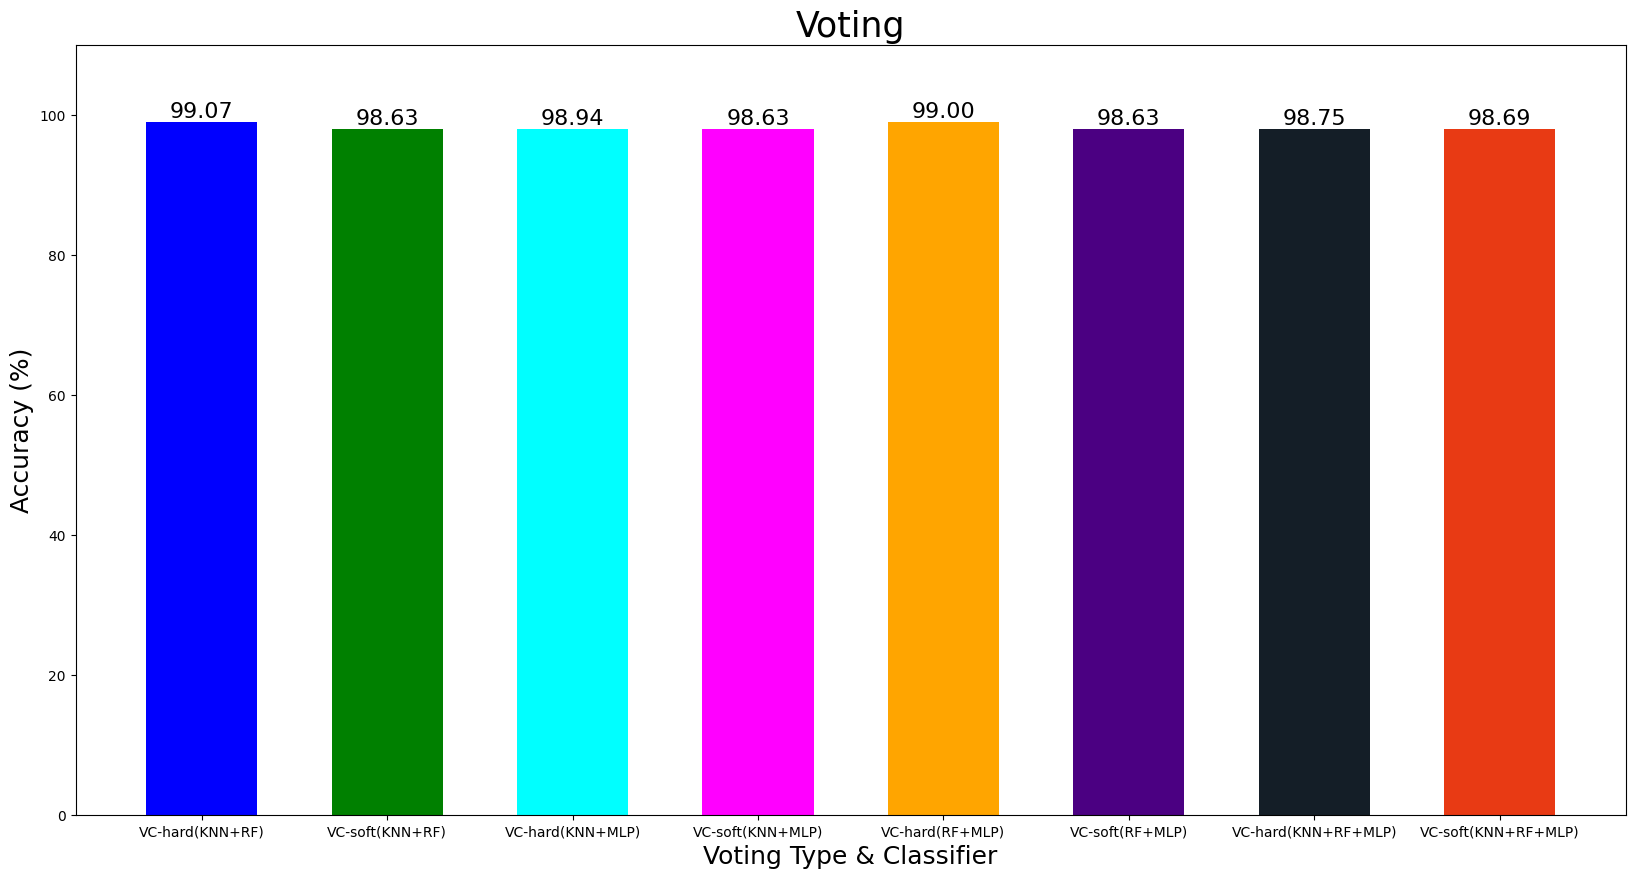

In [ ]:
plt.figure(figsize=(20,10))
algo = ['VC-hard(KNN+RF)', 'VC-soft(KNN+RF)', 'VC-hard(KNN+MLP)', 'VC-soft(KNN+MLP)', 'VC-hard(RF+MLP)', 'VC-soft(RF+MLP)', 'VC-hard(KNN+RF+MLP)', 'VC-soft(KNN+RF+MLP)']
acc = [math.floor(int(float(a1))),math.floor(int(float(b1))),math.floor(int(float(a2))),math.floor(int(float(b2))),math.floor(int(float(a3))),math.floor(int(float(b3))),math.floor(int(float(a4))),math.floor(int(float(b4)))]
pert = [a1, b1, a2, b2, a3, b3, a4, b4]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14']
plt.bar(algo, acc,color=colors,width=0.6)
plt.title('Voting', color = 'black', fontsize= 25)
plt.xlabel('Voting Type & Classifier', fontsize= 18)
plt.ylabel('Accuracy (%)', fontsize= 18)
plt.ylim(0,110)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

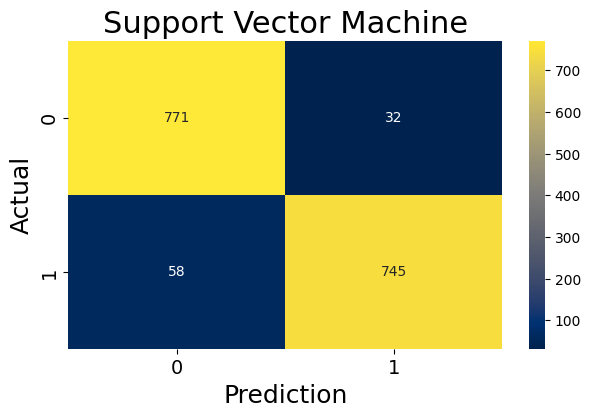

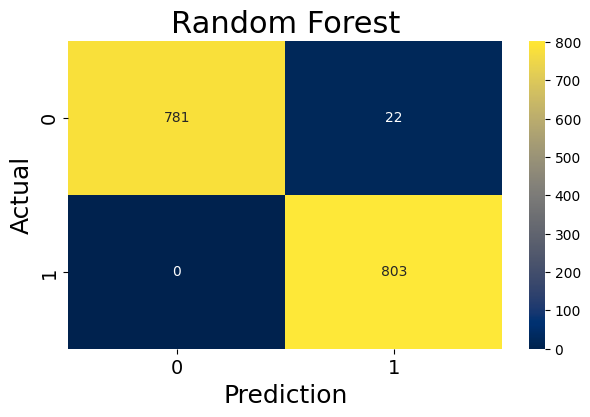

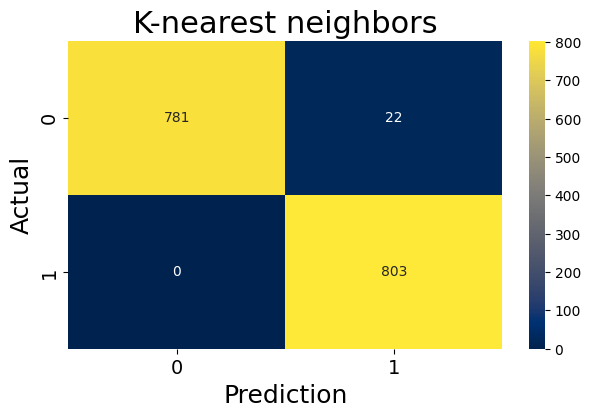

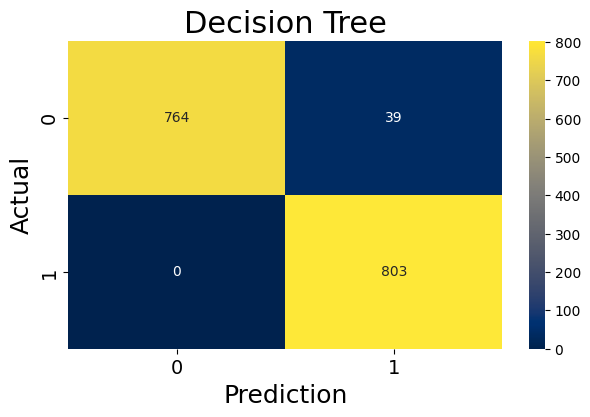

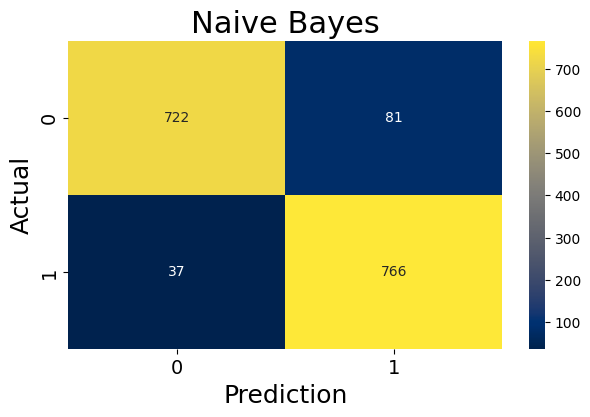

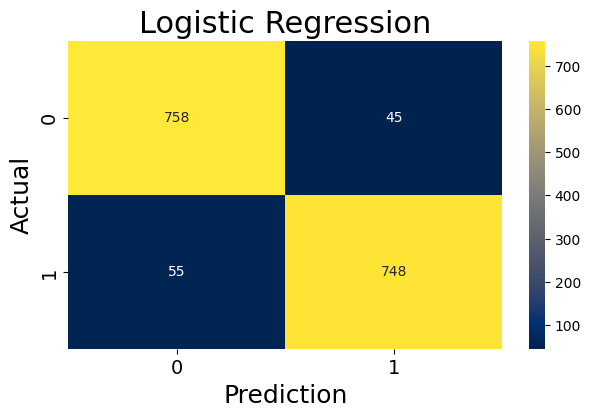

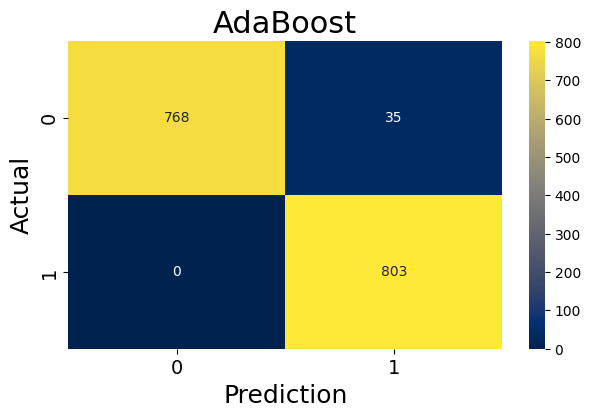

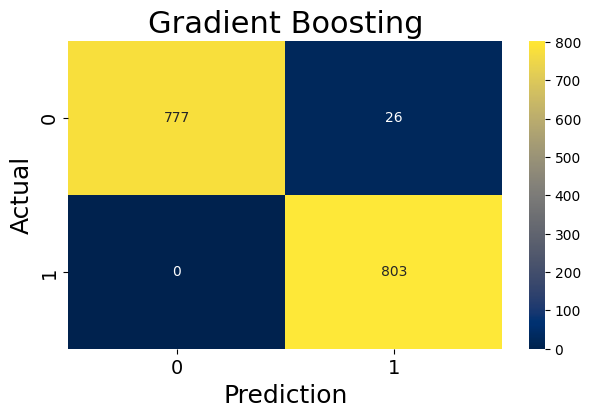

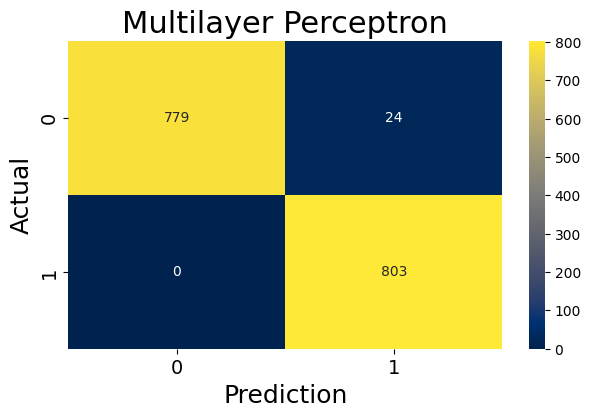

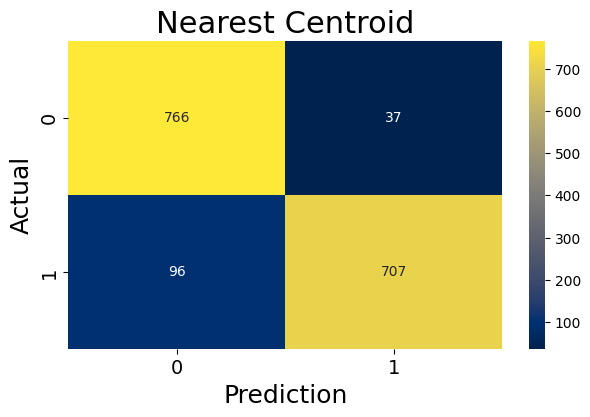

In [ ]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (7,4), fontsize=14, title = "Confusion Matrix"):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cmap='cividis')
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=90, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=0, ha='center', fontsize=fontsize)
    plt.ylabel('Actual', fontsize=18, color='black')
    plt.xlabel('Prediction',  fontsize=18, color='black')
    plt.title(title, fontsize=22, color='black')

cm = confusion_matrix(y_os, svm_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Support Vector Machine")

cm = confusion_matrix(y_os, rf_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Random Forest")

cm = confusion_matrix(y_os, knn_y_pre)
print_confusion_matrix(cm,["0", "1"], title="K-nearest neighbors")

cm = confusion_matrix(y_os, dt_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Decision Tree")

cm = confusion_matrix(y_os, nb_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Naive Bayes")

cm = confusion_matrix(y_os, lr_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Logistic Regression")

cm = confusion_matrix(y_os, ab_y_pre)
print_confusion_matrix(cm,["0", "1"], title="AdaBoost")

cm = confusion_matrix(y_os, gb_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Gradient Boosting")

cm = confusion_matrix(y_os, mlp_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Multilayer Perceptron")

cm = confusion_matrix(y_os, ncc_y_pre)
print_confusion_matrix(cm,["0", "1"], title="Nearest Centroid")



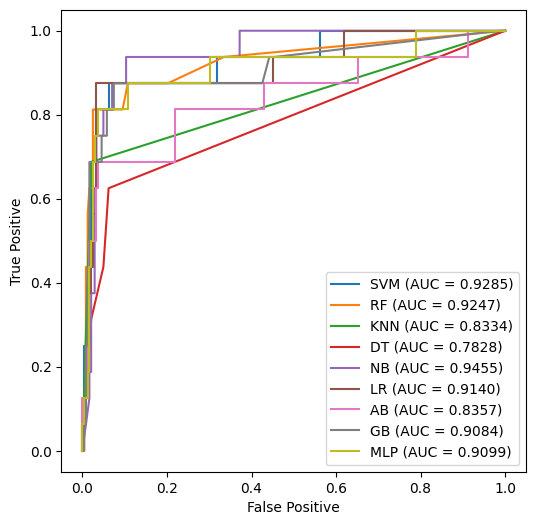

In [ ]:
svm.fit(x_train, y_train)
a_svm = svm.decision_function(x_test)

RF.fit(x_train, y_train)
a_RF = RF.predict_proba(x_test)

KNN.fit(x_train, y_train)
a_KNN = KNN.predict_proba(x_test)

DT.fit(x_train, y_train)
a_DT = DT.predict_proba(x_test)

NB.fit(x_train, y_train)
a_NB = NB.predict_proba(x_test)

LR.fit(x_train, y_train)
a_LR = LR.decision_function(x_test)

AB.fit(x_train, y_train)
a_AB = AB.predict_proba(x_test)

GB.fit(x_train, y_train)
a_GB = GB.predict_proba(x_test)

MLP.fit(x_train, y_train)
a_MLP = MLP.predict_proba(x_test)

#NCC.fit(x_train, y_train)
#a_NCC = NCC.decision_function(x_test)


from sklearn.metrics import roc_curve, auc

#ROC for svm
svm_fpr, svm_tpr, threshold = roc_curve(y_test, a_svm)
auc_svm = auc(svm_fpr, svm_tpr)

#ROC for RF
RF_fpr, RF_tpr, threshold = roc_curve(y_test, a_RF[:,1])
auc_RF = auc(RF_fpr, RF_tpr)

#ROC for KNN
KNN_fpr, KNN_tpr, threshold = roc_curve(y_test, a_KNN[:,1])
auc_KNN = auc(KNN_fpr, KNN_tpr)

#ROC for DT
DT_fpr, DT_tpr, threshold = roc_curve(y_test, a_DT[:,1])
auc_DT = auc(DT_fpr, DT_tpr)

#ROC for NB
NB_fpr, NB_tpr, threshold = roc_curve(y_test, a_NB[:,1])
auc_NB = auc(NB_fpr, NB_tpr)

#ROC for LR
logistic_fpr, logistic_tpr, threshold = roc_curve(y_test, a_LR)
auc_logistic = auc(logistic_fpr, logistic_tpr)

#ROC for AB
AB_fpr, AB_tpr, threshold = roc_curve(y_test, a_AB[:,1])
auc_AB = auc(AB_fpr, AB_tpr)

#ROC for GB
GB_fpr, GB_tpr, threshold = roc_curve(y_test, a_GB[:,1])
auc_GB = auc(GB_fpr, GB_tpr)

#ROC for MLP
MLP_fpr, MLP_tpr, threshold = roc_curve(y_test, a_MLP[:,1])
auc_MLP = auc(MLP_fpr, MLP_tpr)

A = ''
B = 'solid'
plt.figure(figsize=(6, 6), dpi=100)
plt.plot(svm_fpr, svm_tpr, marker=A, linestyle=B, label='SVM (AUC = %0.4f)' % auc_svm)
plt.plot(RF_fpr, RF_tpr, marker=A, linestyle=B, label='RF (AUC = %0.4f)' % auc_RF)
plt.plot(KNN_fpr, KNN_tpr, marker=A, linestyle=B, label='KNN (AUC = %0.4f)' % auc_KNN)
plt.plot(DT_fpr, DT_tpr, marker=A, linestyle=B, label='DT (AUC = %0.4f)' % auc_DT)
plt.plot(NB_fpr, NB_tpr, marker=A, linestyle=B, label='NB (AUC = %0.4f)' % auc_NB)
plt.plot(logistic_fpr, logistic_tpr, marker=A, linestyle=B, label='LR (AUC = %0.4f)' % auc_logistic)
plt.plot(AB_fpr, AB_tpr, marker=A, linestyle=B, label='AB (AUC = %0.4f)' % auc_AB)
plt.plot(GB_fpr, GB_tpr, marker=A, linestyle=B, label='GB (AUC = %0.4f)' % auc_GB)
plt.plot(MLP_fpr, MLP_tpr, marker=A, linestyle=B, label='MLP (AUC = %0.4f)' % auc_MLP)

plt.xlabel('False Positive')
plt.ylabel('True Positive')

plt.legend()
plt.show()

